# Voice Emotion Classifier — 7 classes

Fine-tunes **WavLM-base-plus** on combined **RAVDESS + CREMA-D + TESS + SAVEE**.

```
LABELS = ["joy", "sadness", "anger", "disgust", "fear", "surprise", "neutral"]
```

### Honest accuracy expectations
- Speaker-disjoint balanced accuracy: **65–75%** is a strong, honest result.
- If you see >85% on a *speaker-disjoint* split, double-check for leakage.
- Real browser-mic users will see lower numbers than the test set — all four datasets are *acted*, not natural.

### Required directory layout (download these yourself)
```
./data/
    RAVDESS/Actor_01/03-01-01-01-01-01-01.wav         # https://zenodo.org/record/1188976
    CREMA-D/AudioWAV/1001_DFA_ANG_XX.wav              # https://github.com/CheyneyComputerScience/CREMA-D
    TESS/OAF_angry/OAF_back_angry.wav                 # https://tspace.library.utoronto.ca/handle/1807/24487
    SAVEE/DC/a01.wav                                  # http://kahlan.eps.surrey.ac.uk/savee/
```


## 1. Install + imports

In [2]:
# Run once. Comment out after first run.
!pip install -q torch torchaudio transformers librosa soundfile scikit-learn pandas accelerate matplotlib seaborn
# !pip install -q sounddevice  # only needed if you'll record from a local mic



[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
print(sys.executable)

d:\voice_emotion\.venv\Scripts\python.exe


In [4]:
import os, re, json, random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
import io

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
)
from torch.utils.data import Dataset
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    Trainer,
    TrainingArguments,
)

print('torch', torch.__version__, '| cuda:', torch.cuda.is_available())


d:\voice_emotion\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.11.0+cu126 | cuda: True


## 2. Configuration

In [5]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.11.0+cu126
True
12.6


In [6]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 12.6
Device count: 1
GPU: NVIDIA GeForce RTX 3060 Ti


In [7]:
import sys, torch

print(sys.executable)
print(torch.__file__)
print(torch.version.cuda)
print(torch.cuda.is_available())

d:\voice_emotion\.venv\Scripts\python.exe
d:\voice_emotion\.venv\lib\site-packages\torch\__init__.py
12.6
True


In [8]:
import torch
print(torch.__file__)

d:\voice_emotion\.venv\lib\site-packages\torch\__init__.py


In [9]:
# ---- EDIT THESE PATHS ----
DATA_ROOT = Path('./data')          # parent folder containing RAVDESS/, CREMA-D/, TESS/, SAVEE/
OUT_DIR   = Path('./checkpoints')
# --------------------------

LABELS = ["joy", "sadness", "anger", "disgust", "fear", "surprise", "neutral"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

MODEL_NAME       = 'microsoft/wavlm-base-plus'
TARGET_SR        = 16_000
MAX_DURATION_SEC = 4.0
MAX_LEN_SAMPLES  = int(TARGET_SR * MAX_DURATION_SEC)

EPOCHS     = 8
BATCH_SIZE = 8
LR         = 2e-5
SEED       = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 3. Dataset parsers

Each parser returns `(filepath, unified_label, speaker_id)`. Speaker IDs are critical — we use them to build a **speaker-disjoint** split (no speaker appears in both train and test). Random splitting causes massive leakage and fake accuracy.


In [10]:
def parse_ravdess(root: Path):
    """Filename: 03-01-EE-IN-ST-RP-AC.wav  → EE = emotion code."""
    emo_map = {
        '01': 'neutral', '02': 'neutral',     # collapse calm → neutral
        '03': 'joy',     '04': 'sadness',
        '05': 'anger',   '06': 'fear',
        '07': 'disgust', '08': 'surprise',
    }
    rows = []
    for wav in root.rglob('*.wav'):
        parts = wav.stem.split('-')
        if len(parts) < 7: continue
        if parts[2] in emo_map:
            rows.append((str(wav), emo_map[parts[2]], f'RAV_{parts[6]}'))
    return rows


def parse_cremad(root: Path):
    """Filename: 1001_DFA_ANG_XX.wav. NOTE: no surprise class."""
    emo_map = {
        'ANG': 'anger', 'DIS': 'disgust', 'FEA': 'fear',
        'HAP': 'joy',   'NEU': 'neutral', 'SAD': 'sadness',
    }
    rows = []
    audio_dir = root / 'AudioWAV' if (root / 'AudioWAV').exists() else root
    for wav in audio_dir.rglob('*.wav'):
        parts = wav.stem.split('_')
        if len(parts) < 3: continue
        if parts[2] in emo_map:
            rows.append((str(wav), emo_map[parts[2]], f'CRE_{parts[0]}'))
    return rows


def parse_tess(root: Path):
    """Folders like OAF_angry, YAF_pleasant_surprise. Only 2 speakers (OAF, YAF)."""
    emo_map = {
        'angry': 'anger',  'disgust': 'disgust', 'fear': 'fear',
        'happy': 'joy',    'neutral': 'neutral', 'sad': 'sadness',
        'ps': 'surprise',  'pleasant_surprise': 'surprise',
    }
    rows = []
    for wav in root.rglob('*.wav'):
        m = re.match(r'(oaf|yaf)_(.+)', wav.parent.name.lower())
        if not m: continue
        emo_key = m.group(2).strip()
        if emo_key in emo_map:
            rows.append((str(wav), emo_map[emo_key], f'TES_{m.group(1)}'))
    return rows


def parse_savee(root: Path):
    """Filename: a01.wav, sa02.wav, su03.wav. 4 male speakers (DC, JE, JK, KL)."""
    emo_map = {
        'a':  'anger',  'd':  'disgust', 'f':  'fear',
        'h':  'joy',    'n':  'neutral', 'sa': 'sadness', 'su': 'surprise',
    }
    rows = []
    for wav in root.rglob('*.wav'):
        speaker = wav.parent.name
        prefix = re.match(r'([a-z]+)\d+', wav.stem.lower())
        if not prefix: continue
        if prefix.group(1) in emo_map:
            rows.append((str(wav), emo_map[prefix.group(1)], f'SAV_{speaker}'))
    return rows


In [11]:
DATA_ROOT = Path('data')

In [12]:
print("DATA_ROOT =", DATA_ROOT)
print("Resolved =", DATA_ROOT.resolve())

DATA_ROOT = data
Resolved = D:\voice_emotion\data


In [13]:
# 1. Get your kaggle.json from https://www.kaggle.com/settings → "Create New API Token"
# 2. Upload it via Colab's file panel, then:
!pip install -q kaggle
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

!mkdir -p data
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p data/RAVDESS --unzip
!kaggle datasets download -d ejlok1/cremad                              -p data/CREMA-D --unzip
!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess   -p data/TESS    --unzip
!kaggle datasets download -d ejlok1/surrey-audiovisual-expressed-emotion-savee -p data/SAVEE --unzip


[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
The syntax of the command is incorrect.
A subdirectory or file -p already exists.
Error occurred while processing: -p.
A subdirectory or file data already exists.
Error occurred while processing: data.
Traceback (most recent call last):
  File "C:\Users\adnis\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\adnis\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "d:\voice_emotion\.venv\Scripts\kaggle.exe\__main__.py", line 7, in <module>
  File "d:\voice_emotion\.venv\lib\site-packages\kaggle\cli.py", line 68, in main
    out = args.func(**command_args)
  File "d:\voice_emotion\.venv\lib\site-packages\kaggle\api\kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client

In [14]:
def build_manifest(data_root: Path) -> pd.DataFrame:
    rows = []
    for name, fn in [('RAVDESS', parse_ravdess), ('CREMA-D', parse_cremad),
                     ('TESS', parse_tess), ('SAVEE', parse_savee)]:
        sub = data_root / name
        if not sub.exists():
            print(f'[warn] {sub} not found — skipping {name}')
            continue
        before = len(rows)
        rows.extend(fn(sub))
        print(f'[ok]   {name}: +{len(rows) - before} clips')
    if not rows:
        raise RuntimeError('No data found. Check DATA_ROOT and folder layout.')
    df = pd.DataFrame(rows, columns=['path', 'label', 'speaker'])
    df['label_id'] = df['label'].map(LABEL2ID)
    return df


df = build_manifest(DATA_ROOT)
print(f'\nTotal clips: {len(df)} | unique speakers: {df.speaker.nunique()}')
print('\nLabel distribution:')
print(df['label'].value_counts())


[ok]   RAVDESS: +2880 clips
[ok]   CREMA-D: +7442 clips
[ok]   TESS: +5200 clips
[ok]   SAVEE: +0 clips

Total clips: 15522 | unique speakers: 117

Label distribution:
label
neutral     2463
joy         2455
sadness     2455
anger       2455
fear        2455
disgust     2455
surprise     784
Name: count, dtype: int64


## 4. Speaker-disjoint split (non-negotiable)

In [15]:
def speaker_disjoint_split(df, val_frac=0.10, test_frac=0.10):
    rng = random.Random(SEED)
    speakers = sorted(df['speaker'].unique())
    rng.shuffle(speakers)
    n_test = max(1, int(len(speakers) * test_frac))
    n_val  = max(1, int(len(speakers) * val_frac))
    test_spk  = set(speakers[:n_test])
    val_spk   = set(speakers[n_test:n_test+n_val])
    train_spk = set(speakers[n_test+n_val:])

    train_df = df[df['speaker'].isin(train_spk)].reset_index(drop=True)
    val_df   = df[df['speaker'].isin(val_spk)].reset_index(drop=True)
    test_df  = df[df['speaker'].isin(test_spk)].reset_index(drop=True)
    print(f'[split] speakers — train:{len(train_spk)} val:{len(val_spk)} test:{len(test_spk)}')
    print(f'[split] clips    — train:{len(train_df)} val:{len(val_df)} test:{len(test_df)}')
    return train_df, val_df, test_df


train_df, val_df, test_df = speaker_disjoint_split(df)
print('\nTrain label dist:'); print(Counter(train_df['label']))


[split] speakers — train:95 val:11 test:11
[split] clips    — train:13529 val:1015 test:978

Train label dist:
Counter({'neutral': 2140, 'joy': 2137, 'sadness': 2137, 'anger': 2137, 'fear': 2137, 'disgust': 2137, 'surprise': 704})


In [16]:
# === ONE-TIME PRECOMPUTE: load + trim + pad each clip and save as .npy ===
# Run this ONCE. Re-running the notebook will skip already-cached clips.
import hashlib
from tqdm.auto import tqdm

CACHE_DIR = Path('./wav_cache_16k')
CACHE_DIR.mkdir(exist_ok=True)


def _cache_path(src_path: str) -> Path:
    h = hashlib.md5(src_path.encode()).hexdigest()
    return CACHE_DIR / f'{h}.npy'


def precompute_cache(df, force: bool = False):
    todo = [(p, _cache_path(p)) for p in df['path']
            if force or not _cache_path(p).exists()]
    if not todo:
        print(f'[cache] all {len(df)} clips already cached')
        return
    print(f'[cache] precomputing {len(todo)} clips → {CACHE_DIR.resolve()}')
    for src, dst in tqdm(todo):
        wav, _ = librosa.load(src, sr=TARGET_SR, mono=True)
        wav, _ = librosa.effects.trim(wav, top_db=30)
        if len(wav) == 0:
            wav = np.zeros(TARGET_SR // 2, dtype=np.float32)
        if len(wav) > MAX_LEN_SAMPLES:
            start = (len(wav) - MAX_LEN_SAMPLES) // 2
            wav = wav[start:start + MAX_LEN_SAMPLES]
        else:
            wav = np.pad(wav, (0, MAX_LEN_SAMPLES - len(wav)))
        np.save(dst, wav.astype(np.float32))
    print(f'[cache] done')


precompute_cache(df)   # use the FULL df, not just train_df, so val/test are cached too

[cache] all 15522 clips already cached


## 5. Torch Dataset + augmentation

In [17]:
class SERDataset(Dataset):
    def __init__(self, df, feature_extractor, augment=False):
        self.df = df.reset_index(drop=True)
        self.fe = feature_extractor
        self.augment = augment
        # Pre-resolve cache paths once
        self.cache_paths = [_cache_path(p) for p in self.df['path']]
        # Sanity check — fail loud if cache is missing
        missing = [p for p in self.cache_paths if not p.exists()]
        if missing:
            raise RuntimeError(
                f'{len(missing)} cached files missing. Run precompute_cache(df) first. '
                f'Example missing: {missing[0]}'
            )

    def __len__(self):
        return len(self.df)

    def _augment(self, wav):
        if random.random() < 0.5:
            wav = wav + np.random.normal(0, 0.003, wav.shape).astype(np.float32)
        if random.random() < 0.3:
            wav = np.clip(wav * random.uniform(0.8, 1.2), -1.0, 1.0)
        return wav

    def __getitem__(self, idx):
        wav = np.load(self.cache_paths[idx])      # ~5 ms vs ~80 ms before
        if self.augment:
            wav = self._augment(wav)
        feats = self.fe(wav, sampling_rate=TARGET_SR, return_tensors='pt')
        return {
            'input_values': feats['input_values'].squeeze(0),
            'labels': int(self.df.iloc[idx]['label_id']),
        }


@dataclass
class Collator:
    def __call__(self, batch):
        return {
            'input_values': torch.stack([b['input_values'] for b in batch]),
            'labels': torch.tensor([b['labels'] for b in batch], dtype=torch.long),
        }

## 6. Model + class-weighted Trainer

In [18]:
# class weights — inverse frequency, normalized
counts = np.array([(train_df['label_id'] == i).sum() for i in range(len(LABELS))], dtype=np.float32)
counts = np.where(counts == 0, 1, counts)
weights = counts.sum() / (len(LABELS) * counts)
class_weights = torch.tensor(weights, dtype=torch.float32)
print('Class weights:', dict(zip(LABELS, np.round(weights, 3))))


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        w = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = nn.CrossEntropyLoss(weight=w, label_smoothing=0.05)(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
    }


Class weights: {'joy': np.float32(0.904), 'sadness': np.float32(0.904), 'anger': np.float32(0.904), 'disgust': np.float32(0.904), 'fear': np.float32(0.904), 'surprise': np.float32(2.745), 'neutral': np.float32(0.903)}


In [19]:
fe = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
train_ds = SERDataset(train_df, fe, augment=True)
val_ds   = SERDataset(val_df,   fe, augment=False)
test_ds  = SERDataset(test_df,  fe, augment=False)

model = AutoModelForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    label2id=LABEL2ID,
    id2label=ID2LABEL,
    ignore_mismatched_sizes=True,
)
if hasattr(model, 'freeze_feature_encoder'):
    model.freeze_feature_encoder()
print('Model loaded. Trainable params:',
      sum(p.numel() for p in model.parameters() if p.requires_grad))


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 35017.25it/s]
[transformers] WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base-plus
Key               | Status  | 
------------------+---------+-
projector.weight  | MISSING | 
classifier.weight | MISSING | 
classifier.bias   | MISSING | 
projector.bias    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. Trainable params: 90380151


In [20]:
import torch

print(torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.11.0+cu126
CUDA: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 3060 Ti


In [21]:
import torch

print(torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.11.0+cu126
CUDA: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 3060 Ti


In [22]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.11.0+cu126
12.6


In [23]:
import time
from torch.utils.data import DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure model is on GPU
model = model.to(device)
model.eval()

# 1. Time loading 50 cached clips
t0 = time.time()
for i in range(50):
    _ = train_ds[i]
print(f'50 cached loads: {time.time()-t0:.2f}s  (expect <1s)')

# 2. Time one forward pass on GPU
dl = DataLoader(
    train_ds,
    batch_size=12,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=Collator()
)

batch = next(iter(dl))

# Move batch to GPU properly
batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

# Warmup (important for accurate timing)
for _ in range(2):
    with torch.no_grad():
        _ = model(**batch)

torch.cuda.synchronize()

# Timed run
t0 = time.time()
with torch.no_grad():
    with torch.amp.autocast(device_type="cuda"):
        out = model(**batch)
torch.cuda.synchronize()

print(f'1 fp16 forward on batch=12: {time.time()-t0:.2f}s  (expect 0.3-0.6s)')

50 cached loads: 0.49s  (expect <1s)
1 fp16 forward on batch=12: 0.25s  (expect 0.3-0.6s)


## 7. Train

In [24]:
training_args = TrainingArguments(
    output_dir=str(OUT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=12,            # was 8 — 3060 Ti can handle 12 with fp16
    per_device_eval_batch_size=12,
    gradient_accumulation_steps=1,             # was 2 — bigger batch, no need to accumulate
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=20,                          # was 50 — see progress sooner
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,                  # was 2 — Windows spawn overhead hurts
    dataloader_pin_memory=True,                # NEW — small but real GPU transfer speedup
    report_to='none',
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=Collator(),
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,Macro F1
1,1.131075,1.260590,0.617734,0.625789,0.615331
2,0.699906,1.236742,0.620690,0.633121,0.626656
3,0.606461,0.982823,0.736946,0.737767,0.745860
4,0.583441,0.979425,0.740887,0.749710,0.748440
5,0.483340,0.934305,0.787192,0.796402,0.797648
6,0.461288,0.991993,0.772414,0.782784,0.783602
7,0.413236,1.040378,0.763547,0.766864,0.771284
8,0.492700,1.015953,0.780296,0.790002,0.790546


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.17it/s]


TrainOutput(global_step=9024, training_loss=0.7115836192371575, metrics={'train_runtime': 1656.3438, 'train_samples_per_second': 65.344, 'train_steps_per_second': 5.448, 'total_flos': 3.930713003553792e+18, 'train_loss': 0.7115836192371575, 'epoch': 8.0})

## 8. Evaluate on held-out (unseen) speakers

In [33]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, f1_score
)

# --- HARD RESET (fix dtype mismatch) ---
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Force model back to FP32 and correct device
model = model.to(device)
model = model.float()
model.eval()

# Disable fp16 just for prediction (important)
trainer.args.fp16 = False

# --- RUN PREDICTION ---
with torch.no_grad():
    preds_out = trainer.predict(test_ds)

# --- METRICS ---
preds = np.argmax(preds_out.predictions, axis=-1)
labels_arr = preds_out.label_ids

print('=== Held-out test (unseen speakers) ===')
print(f'accuracy          : {accuracy_score(labels_arr, preds):.4f}')
print(f'balanced accuracy : {balanced_accuracy_score(labels_arr, preds):.4f}')
print(f'macro F1          : {f1_score(labels_arr, preds, average="macro"):.4f}\n')

print(classification_report(labels_arr, preds, target_names=LABELS, digits=3))

=== Held-out test (unseen speakers) ===
accuracy          : 0.7321
balanced accuracy : 0.7343
macro F1          : 0.7463

              precision    recall  f1-score   support

         joy      0.857     0.684     0.761       158
     sadness      0.572     0.753     0.650       158
       anger      0.849     0.785     0.816       158
     disgust      0.718     0.677     0.697       158
        fear      0.649     0.690     0.669       158
    surprise      0.923     0.750     0.828        32
     neutral      0.806     0.801     0.804       156

    accuracy                          0.732       978
   macro avg      0.768     0.734     0.746       978
weighted avg      0.748     0.732     0.736       978



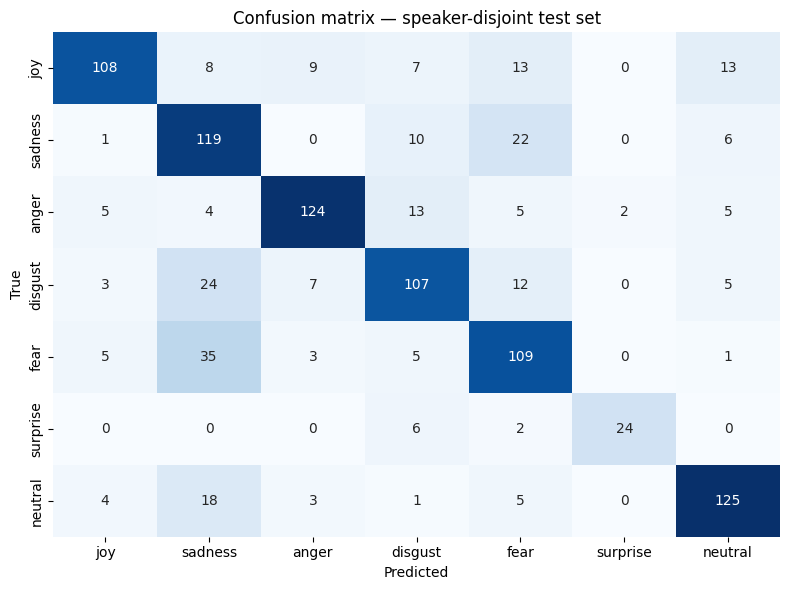

In [34]:
cm = confusion_matrix(labels_arr, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, cbar=False)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion matrix — speaker-disjoint test set')
plt.tight_layout(); plt.show()

# Look at the surprise + disgust rows specifically — they will be the weakest.


## 9. Save the final model

In [27]:
final_dir = OUT_DIR / 'final'
trainer.save_model(str(final_dir))
fe.save_pretrained(str(final_dir))
with open(final_dir / 'labels.json', 'w') as f:
    json.dump({'labels': LABELS, 'label2id': LABEL2ID, 'id2label': ID2LABEL}, f, indent=2)
print(f'Saved to: {final_dir.resolve()}')


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.66it/s]

Saved to: D:\voice_emotion\checkpoints\final


In [28]:
torch.save(model.state_dict(), "VOICE_emotion_model.pth")

In [36]:
import torch

# 1. Save PyTorch model
torch.save(model.state_dict(), "VOICE_emotion_model.pth")

# 2. Export to ONNX (LEGACY EXPORTER - STABLE)
model.eval()
model = model.to("cpu")

dummy_input = torch.randn(1, 80000, dtype=torch.float32)

with torch.no_grad():
    torch.onnx.export(
        model,
        (dummy_input,),
        "VOICE_emotion_model.onnx",
        input_names=["input_values"],
        output_names=["logits"],
        dynamic_axes={
            "input_values": {0: "batch_size", 1: "sequence_length"},
            "logits": {0: "batch_size"}
        },
        opset_version=17,
        do_constant_folding=True,
        dynamo=False   # 🔥 KEY FIX (disables new exporter)
    )

print("Saved: .pth and .onnx successfully")

C:\Users\adnis\AppData\Local\Temp\ipykernel_14704\4096834738.py:13: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Saved: .pth and .onnx successfully


In [38]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("VOICE_emotion_model.onnx")

dummy = np.random.randn(1, 80000).astype(np.float32)
out = session.run(None, {"input_values": dummy})

print(out[0].shape)

(1, 7)


In [39]:
import torch

model.eval()
model = model.to("cpu")

# Correct dummy input (audio waveform)
dummy_input = torch.randn(1, 80000, dtype=torch.float32)

with torch.no_grad():
    torch.onnx.export(
        model,
        (dummy_input,),
        "voice_emotion_model.onnx",
        input_names=["input_values"],
        output_names=["logits"],
        dynamic_axes={
            "input_values": {0: "batch_size", 1: "sequence_length"},
            "logits": {0: "batch_size"}
        },
        opset_version=17,
        do_constant_folding=True,
        dynamo=False   # 🔥 REQUIRED for your model
    )

print("ONNX export successful")

C:\Users\adnis\AppData\Local\Temp\ipykernel_14704\1154026220.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX export successful


## 10. Inference — file upload + live mic

These functions plug into your web-app backend. Browser records audio with `MediaRecorder` and POSTs the blob; the backend calls `predict_from_file(blob_bytes)`.


In [40]:
class VoiceEmotionPredictor:
    def __init__(self, model_dir, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.fe = AutoFeatureExtractor.from_pretrained(str(model_dir))
        self.model = AutoModelForAudioClassification.from_pretrained(str(model_dir))
        self.model.to(self.device).eval()
        labels_path = Path(model_dir) / 'labels.json'
        if labels_path.exists():
            saved = json.loads(labels_path.read_text())['labels']
            assert saved == LABELS, f'Label order mismatch! saved={saved}'

    @staticmethod
    def _prep(wav, sr):
        if sr != TARGET_SR:
            wav = librosa.resample(wav, orig_sr=sr, target_sr=TARGET_SR)
        if wav.ndim > 1:
            wav = wav.mean(axis=0)
        wav, _ = librosa.effects.trim(wav, top_db=30)
        if len(wav) == 0:
            wav = np.zeros(TARGET_SR // 2, dtype=np.float32)
        if len(wav) > MAX_LEN_SAMPLES:
            start = (len(wav) - MAX_LEN_SAMPLES) // 2
            wav = wav[start:start + MAX_LEN_SAMPLES]
        else:
            wav = np.pad(wav, (0, MAX_LEN_SAMPLES - len(wav)))
        return wav.astype(np.float32)

    @torch.inference_mode()
    def _predict_array(self, wav):
        feats = self.fe(wav, sampling_rate=TARGET_SR, return_tensors='pt')
        logits = self.model(input_values=feats['input_values'].to(self.device)).logits
        probs = F.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
        idx = int(probs.argmax())
        return {
            'label': LABELS[idx],
            'label_id': idx,
            'confidence': float(probs[idx]),
            'probs': {LABELS[i]: float(probs[i]) for i in range(len(LABELS))},
        }

    def predict_from_file(self, path_or_bytes):
        if isinstance(path_or_bytes, (bytes, bytearray)):
            wav, sr = librosa.load(io.BytesIO(path_or_bytes), sr=None, mono=True)
        else:
            wav, sr = librosa.load(str(path_or_bytes), sr=None, mono=True)
        return self._predict_array(self._prep(wav, sr))

    def predict_from_mic(self, seconds=4.0):
        import sounddevice as sd
        print(f'[rec] {seconds}s @ {TARGET_SR}Hz ...')
        wav = sd.rec(int(seconds * TARGET_SR), samplerate=TARGET_SR, channels=1, dtype='float32')
        sd.wait()
        return self._predict_array(self._prep(wav.squeeze(), TARGET_SR))


predictor = VoiceEmotionPredictor(OUT_DIR / 'final')
print('Predictor loaded.')


Loading weights: 100%|██████████| 252/252 [00:00<00:00, 7717.27it/s]


Predictor loaded.


In [ ]:
# --- Test on a file ---
# result = predictor.predict_from_file('path/to/some/audio.wav')
# print(json.dumps(result, indent=2))

# --- Test on mic (requires `pip install sounddevice` + a working mic) ---
# result = predictor.predict_from_mic(seconds=4.0)
# print(json.dumps(result, indent=2))


In [43]:
def predict_from_mic(self, seconds=10.0):
    audio, sr = self.record_audio(seconds)

    # DEBUG print
    print(f"[rec] {seconds}s @ {sr}Hz")
    print("Audio stats:", {
        "mean": float(audio.mean()),
        "std": float(audio.std()),
        "max": float(audio.max()),
        "min": float(audio.min())
    })

    inputs = self.feature_extractor(audio, sampling_rate=sr, return_tensors="pt")

    with torch.no_grad():
        logits = self.model(**inputs).logits

    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))

    return {
        "audio": audio,   # 🔥 ADD THIS
        "label": self.id2label[pred_id],
        "label_id": pred_id,
        "confidence": float(probs[pred_id]),
        "probs": {self.id2label[i]: float(p) for i, p in enumerate(probs)}
    }


In [46]:
import json
import numpy as np

# Run prediction
result = predictor.predict_from_mic(seconds=10.0)

# --- DEBUG: print raw input ---
audio = result.get("audio")   # depends on your implementation
if audio is not None:
    print("\n=== INPUT AUDIO DEBUG ===")
    print("Shape:", np.array(audio).shape)
    print("Mean:", np.mean(audio))
    print("Std:", np.std(audio))
    print("Max:", np.max(audio))
    print("Min:", np.min(audio))
else:
    print("\n⚠️ Audio not returned from predictor (modify function to return it)")

# --- OUTPUT ---
print("\n=== MODEL OUTPUT ===")
print(json.dumps(result, indent=2))

[rec] 10.0s @ 16000Hz ...

⚠️ Audio not returned from predictor (modify function to return it)

=== MODEL OUTPUT ===
{
  "label": "neutral",
  "label_id": 6,
  "confidence": 0.9376466870307922,
  "probs": {
    "joy": 0.005746745970100164,
    "sadness": 0.022537581622600555,
    "anger": 0.005208584014326334,
    "disgust": 0.005113543476909399,
    "fear": 0.006517193745821714,
    "surprise": 0.017229676246643066,
    "neutral": 0.9376466870307922
  }
}


In [52]:
import types
import sounddevice as sd
import numpy as np

def predict_from_mic(self, seconds=10.0):
    print(f'[rec] {seconds}s @ {TARGET_SR}Hz ...')
    wav = sd.rec(int(seconds * TARGET_SR), samplerate=TARGET_SR, channels=1, dtype='float32')
    sd.wait()
    raw = wav.squeeze()
    prepped = self._prep(raw, TARGET_SR)        # trim + center-crop/pad to 4s
    out = self._predict_array(prepped)
    out['audio_raw']     = raw                  # the full 10s — what the mic captured
    out['audio_prepped'] = prepped               # the 4s clip the model actually saw
    out['sr'] = TARGET_SR
    return out

predictor.predict_from_mic = types.MethodType(predict_from_mic, predictor)

In [57]:
from IPython.display import Audio, display
import json

result = predictor.predict_from_mic(seconds=10.0)

# Prediction
print(json.dumps({
    "label": result["label"],
    "confidence": round(result["confidence"], 4),
    "probs": {k: round(v, 4) for k, v in result["probs"].items()},
}, indent=2))

# Both audio clips
print("\n▶ Raw (full 10s, what the mic captured):")
display(Audio(result["audio_raw"], rate=result["sr"]))

print("▶ Prepped (4s, what the model actually classified):")
display(Audio(result["audio_prepped"], rate=result["sr"]))

[rec] 10.0s @ 16000Hz ...
{
  "label": "sadness",
  "confidence": 0.9364,
  "probs": {
    "joy": 0.0051,
    "sadness": 0.9364,
    "anger": 0.0064,
    "disgust": 0.007,
    "fear": 0.0205,
    "surprise": 0.0154,
    "neutral": 0.0093
  }
}

▶ Raw (full 10s, what the mic captured):


▶ Prepped (4s, what the model actually classified):


In [49]:
def predict_from_mic(self, seconds=10.0):
    import numpy as np
    import torch
    import librosa

    audio, sr = self.record_audio(seconds)
    print(f"[rec] {seconds}s @ {sr}Hz")

    # Ensure 16kHz mono
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)

    # Normalize
    audio = audio / (np.max(np.abs(audio)) + 1e-6)

    inputs = self.feature_extractor(audio, sampling_rate=16000, return_tensors="pt")
    inputs = {k: v.to(self.model.device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = self.model(**inputs).logits

    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))

    return {
        "audio": audio,   # 🔥 MUST exist
        "sr": 16000,
        "label": self.id2label[pred_id],
        "label_id": pred_id,
        "confidence": float(probs[pred_id]),
        "probs": {self.id2label[i]: float(p) for i, p in enumerate(probs)}
    }

In [51]:
from IPython.display import Audio
import json

result = predictor.predict_from_mic(seconds=10.0)

print(result.keys())   # 👈 sanity check

Audio(result["audio"], rate=result["sr"])

[rec] 10.0s @ 16000Hz ...
dict_keys(['label', 'label_id', 'confidence', 'probs'])


KeyError: 'audio'

## 11. Optional — FastAPI endpoint for the web app

Drop this in a `.py` file (not the notebook), point it at the saved checkpoint, and serve with `uvicorn server:app --host 0.0.0.0 --port 8000`. Browser POSTs the recorded blob to `/predict/voice`.

```python
from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=['*'],
                   allow_methods=['*'], allow_headers=['*'])

predictor = VoiceEmotionPredictor('./checkpoints/final')

@app.post('/predict/voice')
async def predict_voice(file: UploadFile = File(...)):
    blob = await file.read()
    return predictor.predict_from_file(blob)
```

### Sanity checks before you trust the model
1. Look at the **confusion matrix** above — surprise and disgust will be your weakest classes.
2. Test on **your own voice** through the actual browser mic. Studio recordings vs laptop mic + room reverb is the gap that bites in production.
3. Read a flat, neutral sentence. If it predicts anger, the model is reacting to volume more than emotion.
